<a href="https://colab.research.google.com/github/izhanys/PBA_Bima_5026231060/blob/main/Tugas/Week%203/Week_3_1_eda_Bima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EDA Google Apps Review-Bima+**

In [ ]:
pip install pandas matplotlib seaborn nltk Sastrawi wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
import re
from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('indonesian'))

Load Data

In [3]:
from google.colab import files
uploaded = files.upload()  # upload df_qpon_rev.csv

import io
for fn in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(f'Loaded {fn}: {len(df):,} rows')

Saving review_bima_75000.csv to review_bima_75000.csv
Loaded review_bima_75000.csv: 75,000 rows


In [4]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,64cf8bb2-43bd-430d-9cde-b23fba4a5d16,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Try gblok gajelas kontl,5,0,NaN,2026-03-10 04:20:37,NaN,NaN,NaN
1,b224d50f-2c03-422f-a632-be4eea88f29a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jangan mahal2 harganya,5,0,NaN,2026-03-10 03:45:42,NaN,NaN,NaN
2,435972c2-7a26-436d-ba68-89cba47a9c60,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,5.12.0,2026-03-10 03:42:26,NaN,NaN,5.12.0
3,41d826a3-1411-4b29-ba43-e3ea2fbd01f8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tri terbaik,4,0,5.13.0,2026-03-10 03:39:43,NaN,NaN,5.13.0
4,e3c550aa-841a-457a-a9cf-218e495ea6cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bgs,5,0,5.12.0,2026-03-10 03:28:51,NaN,NaN,5.12.0


Data Overview

In [5]:
df['at'] = pd.to_datetime(df['at'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              75000 non-null  object        
 1   userName              75000 non-null  object        
 2   userImage             75000 non-null  object        
 3   content               75000 non-null  object        
 4   score                 75000 non-null  int64         
 5   thumbsUpCount         75000 non-null  int64         
 6   reviewCreatedVersion  63766 non-null  object        
 7   at                    75000 non-null  datetime64[ns]
 8   replyContent          74888 non-null  object        
 9   repliedAt             74888 non-null  object        
 10  appVersion            63766 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 6.3+ MB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,64cf8bb2-43bd-430d-9cde-b23fba4a5d16,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Try gblok gajelas kontl,5,0,NaN,2026-03-10 04:20:37,NaN,NaN,NaN
1,b224d50f-2c03-422f-a632-be4eea88f29a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jangan mahal2 harganya,5,0,NaN,2026-03-10 03:45:42,NaN,NaN,NaN
2,435972c2-7a26-436d-ba68-89cba47a9c60,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,5.12.0,2026-03-10 03:42:26,NaN,NaN,5.12.0
3,41d826a3-1411-4b29-ba43-e3ea2fbd01f8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tri terbaik,4,0,5.13.0,2026-03-10 03:39:43,NaN,NaN,5.13.0
4,e3c550aa-841a-457a-a9cf-218e495ea6cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bgs,5,0,5.12.0,2026-03-10 03:28:51,NaN,NaN,5.12.0


In [6]:
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0])

Missing values:
reviewCreatedVersion    11234
replyContent              112
repliedAt                 112
appVersion              11234
dtype: int64


Review Score Distribution

/tmp/ipykernel_41536/3265126195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['score'], palette='viridis')


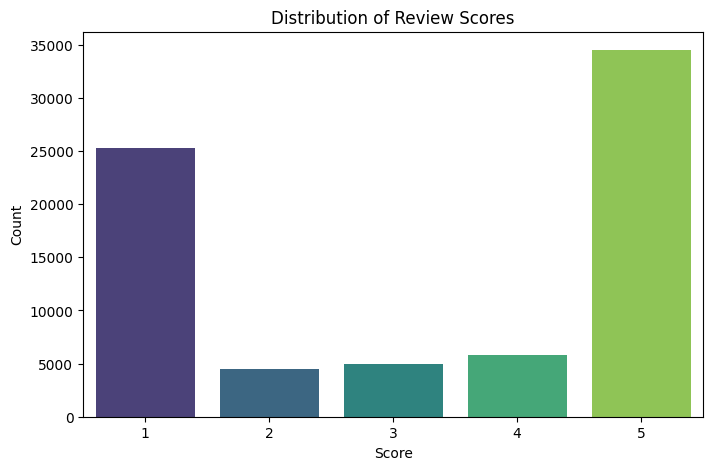

score
1    25286
2     4479
3     4945
4     5786
5    34504
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df['score'], palette='viridis')
plt.title('Distribution of Review Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

print(df['score'].value_counts().sort_index())

In [ ]:
Reviews per Year

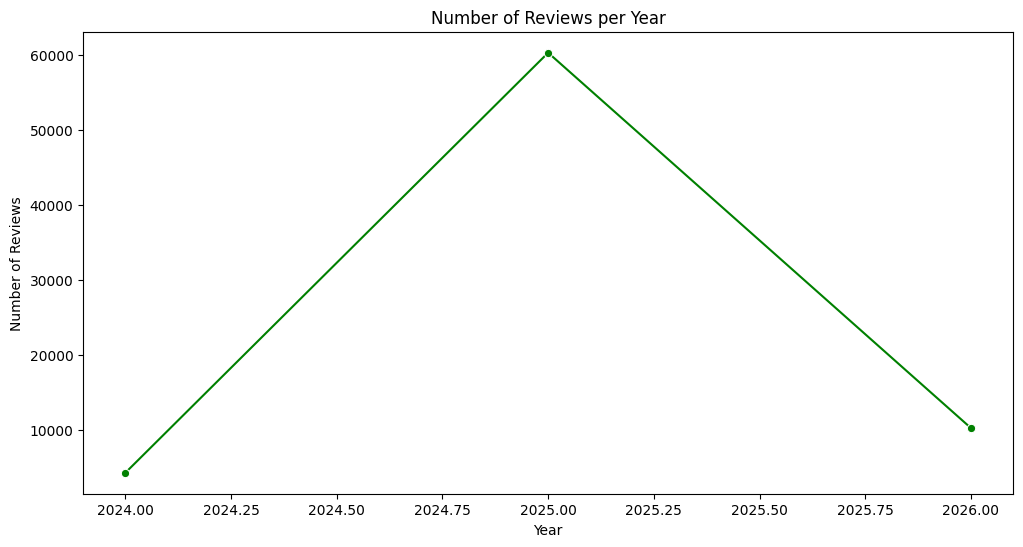

In [8]:
df['year'] = df['at'].dt.year
year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

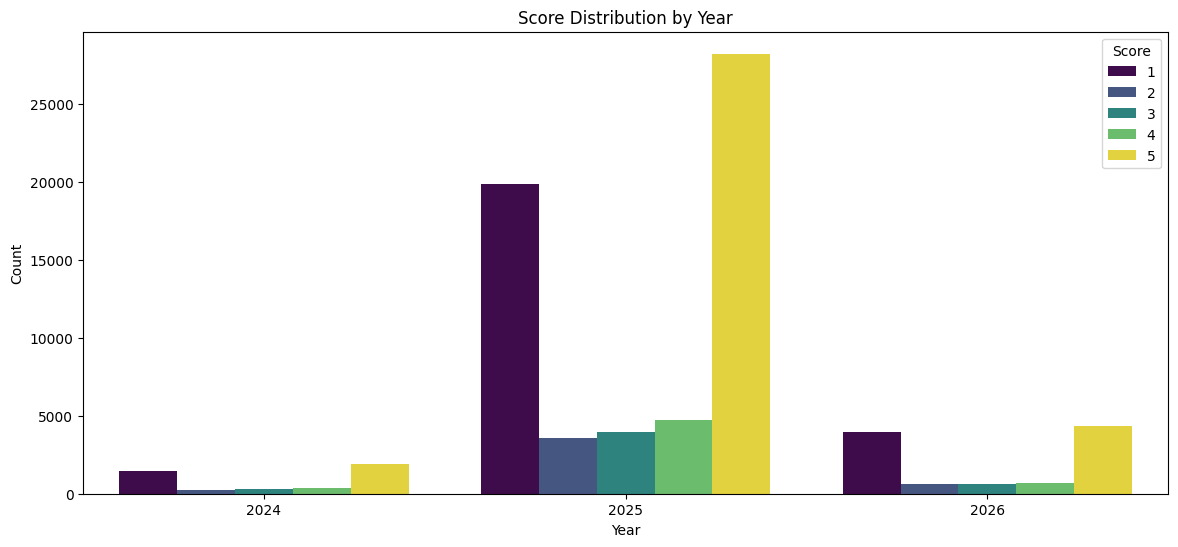

In [9]:
plt.figure(figsize=(14, 6))
sns.countplot(x='year', hue='score', data=df, palette='viridis')
plt.title('Score Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Score')
plt.show()

Review Trends Over Time

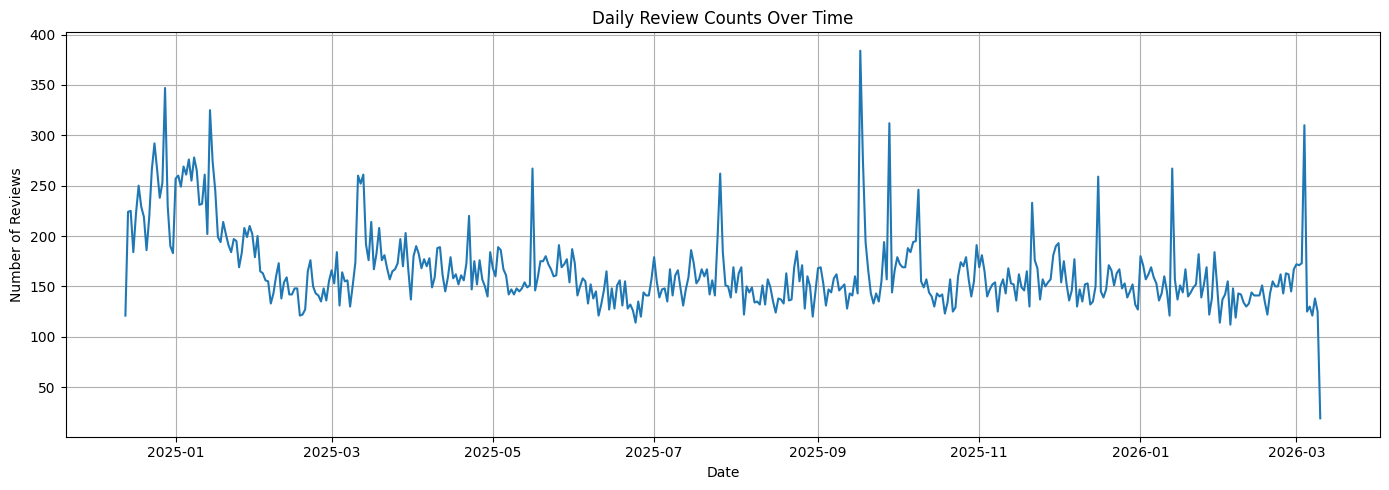

In [10]:
df['review_date'] = df['at'].dt.date
review_trend = df.groupby('review_date').size()

plt.figure(figsize=(14, 5))
review_trend.plot()
plt.title('Daily Review Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.tight_layout()
plt.show()

Word Frequency Analysis

/tmp/ipykernel_41536/3063384834.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_df, x='word', y='count', palette='viridis')


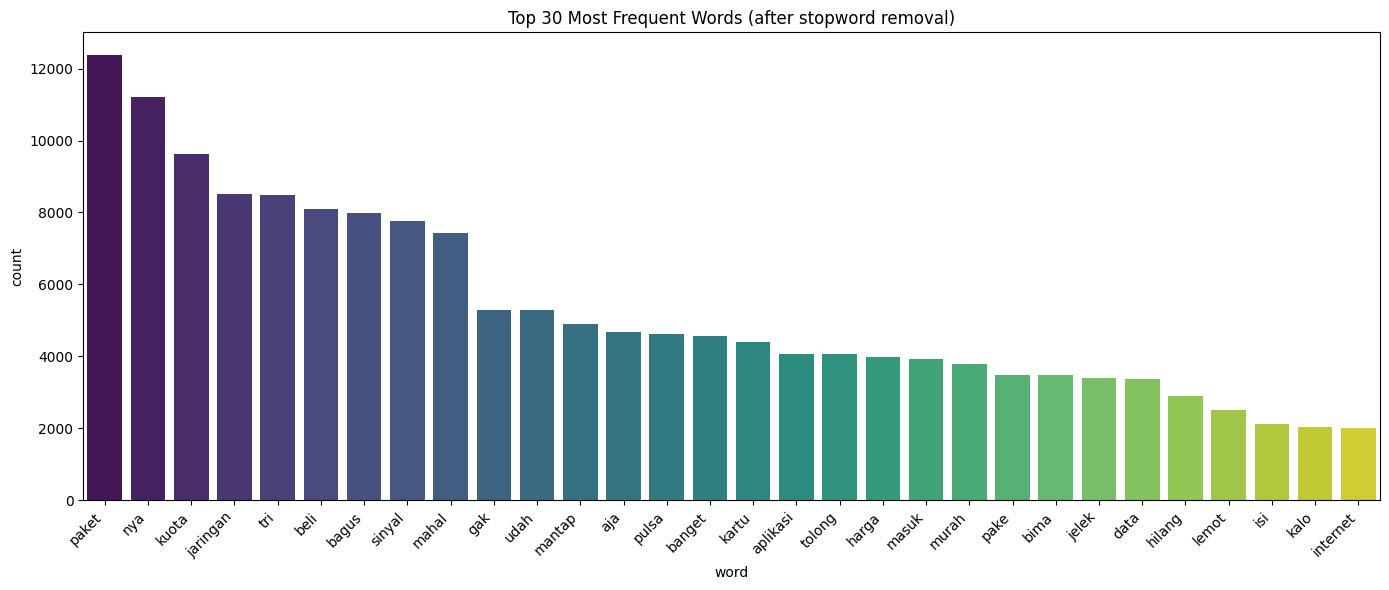

In [11]:
all_reviews = ' '.join(df['content'].dropna().astype(str)).lower()
all_reviews = all_reviews.translate(str.maketrans('', '', string.punctuation))

words = all_reviews.split()
filtered = [w for w in words if w not in stop_words and len(w) > 2]
word_counts = Counter(filtered)

top30 = word_counts.most_common(30)
top_df = pd.DataFrame(top30, columns=['word', 'count'])

plt.figure(figsize=(14, 6))
sns.barplot(data=top_df, x='word', y='count', palette='viridis')
plt.title('Top 30 Most Frequent Words (after stopword removal)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Word Cloud

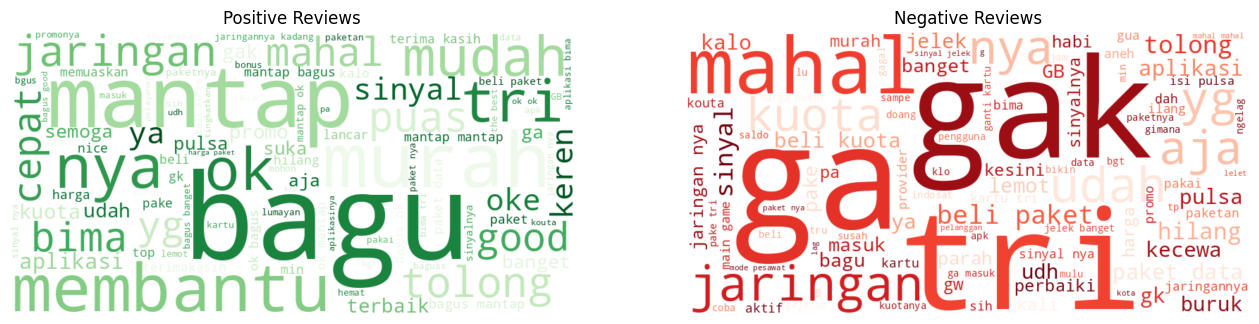

In [12]:
df['sentiment'] = df['score'].apply(lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral'))

def make_cloud(text, title, cmap):
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100,
                   stopwords=stop_words).generate(text)
    return wc

pos_text = ' '.join(df[df['sentiment'] == 'positive']['content'].dropna().astype(str))
neg_text = ' '.join(df[df['sentiment'] == 'negative']['content'].dropna().astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(make_cloud(pos_text, 'Positive', 'Greens'), interpolation='bilinear')
axes[0].set_title('Positive Reviews')
axes[0].axis('off')

axes[1].imshow(make_cloud(neg_text, 'Negative', 'Reds'), interpolation='bilinear')
axes[1].set_title('Negative Reviews')
axes[1].axis('off')
plt.show()